In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr
from category_encoders import TargetEncoder
from lightgbm import LGBMRegressor
import optuna
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping, log_evaluation

In [111]:
df = pd.read_csv("Dataset/car_auction_train.csv")
df.head()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice
0,2012,Kia,Soul,+,Wagon,automatic,ne,4.0,53070.0,gray,black,10100
1,2012,Honda,Civic,LX,Sedan,automatic,ga,2.6,45085.0,gray,gray,10300
2,2002,Honda,Civic,EX,Sedan,automatic,ca,2.2,136649.0,black,gray,3300
3,2002,Dodge,Grand Caravan,Sport,Minivan,automatic,oh,1.9,156991.0,silver,gray,600
4,2010,Chevrolet,Silverado 1500,LT,Crew Cab,NaN,fl,3.4,42421.0,blue,black,21100


# Step 1 - Data Cleaning & Exploratory Data Analysis

In [112]:
df.shape

(447048, 12)

In [113]:
list(df.columns)

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'sellingprice']

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447048 entries, 0 to 447047
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          447048 non-null  int64  
 1   make          438761 non-null  object 
 2   model         438676 non-null  object 
 3   trim          438478 non-null  object 
 4   body          436455 non-null  object 
 5   transmission  394749 non-null  object 
 6   state         447048 non-null  object 
 7   condition     437611 non-null  float64
 8   odometer      446979 non-null  float64
 9   color         426687 non-null  object 
 10  interior      432893 non-null  object 
 11  sellingprice  447048 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 40.9+ MB


Assigned Data Types to the columns are appropriate 

In [115]:
df.describe()

,year,condition,odometer,sellingprice
count,447048.000000,437611.000000,446979.000000,447048.000000
mean,2010.035294,3.424681,68353.615745,13609.877854
std,3.967981,0.950395,53455.257534,9756.832996
min,1982.000000,1.000000,1.000000,1.000000
25%,2007.000000,2.700000,28388.500000,6900.000000
50%,2012.000000,3.600000,52321.000000,12100.000000
75%,2013.000000,4.200000,99139.000000,18200.000000
max,2015.000000,5.000000,999999.000000,230000.000000


In [116]:
df.describe(include='object')

,make,model,trim,body,transmission,state,color,interior
count,438761,438676,438478,436455,394749,447048,426687,432893
unique,93,954,1902,84,2,38,19,16
top,Ford,Altima,Base,Sedan,automatic,fl,black,black
freq,75016,15459,44656,159574,380708,66371,88822,195185


### Missing Value Analysis

In [117]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

              missing_count  missing_pct
transmission          52299    11.698744
color                 20361     4.554544
interior              14155     3.166327
body                  10593     2.369544
condition              9437     2.110959
trim                   8570     1.917020
model                  8372     1.872730
make                   8287     1.853716
odometer                 69     0.015435


condition, trim, model and make has very close missing count, I also have to check if theirs a correlation there

In [118]:
# count rows where model, make and trim are ALL missing
miss_together = df[['trim','make','model']].isnull().all(axis=1)
miss_count = miss_together.sum()
miss_pct = miss_together.mean() * 100

miss_count, miss_pct

(np.int64(8287), np.float64(1.8537159320699343))

#### Interesting, n(trim intersection make) = n(model intersection make) = n(make) implying if 'make' is missing then trim and model is also missing

#### Since, 'make' and 'model', imputing them can give false positives, as they are a big driver for the target column and also since the missing_pct < 2%, I will be just dropping the missing rows, Also since make and model are so important for the value of the car, I can't bid on the car if model or make is not provided so its better to drop them

In [119]:
df = df.dropna(subset=['make','model','trim'])

#### For transmission,color or body, lets check if its MCAR or MNAR.

In [120]:
df['transmission_missing'] = df['transmission'].isnull().astype(int)

print(df.groupby('body')['transmission_missing'].mean().sort_values(ascending=False))



body
e-series van               0.451505
E-Series Van               0.361921
cts coupe                  0.304348
CTS-V Coupe                0.291667
granturismo convertible    0.250000
                             ...   
promaster cargo van        0.000000
Q60 Coupe                  0.000000
Ram Van                    0.000000
cab plus 4                 0.000000
xtracab                    0.000000
Name: transmission_missing, Length: 84, dtype: float64


In [121]:
print(df.groupby('year')['transmission_missing'].mean().sort_values(ascending=False))

year
1990    0.216216
1993    0.179856
1999    0.155201
1996    0.153213
1992    0.148515
1995    0.147793
2012    0.133492
2011    0.130307
1998    0.129642
2001    0.129398
1997    0.128111
2000    0.127971
2014    0.127628
2002    0.127159
1991    0.125000
2015    0.122446
2003    0.118112
1994    0.113793
2004    0.109741
2010    0.108783
2013    0.103949
2008    0.099269
2009    0.098793
2007    0.096338
2005    0.094393
2006    0.092710
1989    0.000000
Name: transmission_missing, dtype: float64


In [122]:
print(df.groupby('condition')['transmission_missing'].mean().sort_values(ascending=False))

condition
1.0    0.157483
5.0    0.148319
4.9    0.139296
4.8    0.133294
4.6    0.132780
4.7    0.132227
4.0    0.129354
4.1    0.125767
1.5    0.125000
3.0    0.124362
4.3    0.123444
4.2    0.122141
4.4    0.120872
2.0    0.119997
4.5    0.117701
3.1    0.117263
3.3    0.116271
1.6    0.114865
3.5    0.113447
3.6    0.112449
3.4    0.111849
3.2    0.111167
3.8    0.110299
3.7    0.109380
2.8    0.107277
3.9    0.106939
2.9    0.106811
2.7    0.102434
2.2    0.101174
2.6    0.100783
2.4    0.099028
2.5    0.098511
2.3    0.098033
2.1    0.093693
1.9    0.093229
1.4    0.085714
1.1    0.084507
1.3    0.078125
1.2    0.075949
1.7    0.071823
1.8    0.065385
Name: transmission_missing, dtype: float64


#### The year doesn't seem to do anything with the missing transmissions, as 1990s have missing transmission while the 1980s doesn't so they are not very much related, althoug for the e-series van , and cts series, seems to be related with the missing transmission, so I would guess this to MAR category

##### Before grouping or building our lookup tables, we must standardize all text columns to lowercase.Converting everything to lowercase ensures our lookup dictionary groups identical vehicles together correctly.

In [123]:
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].str.lower()
    

##### To prevent data leakage, we must split the dataset into training (80%) and validation (20%) sets before calculating any statistics or imputation rules.

In [124]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.copy()
val_df = val_df.copy()

##### We calculate the imputation modes strictly on `train_df` and save them to our `master_encoders` dictionary.
##### We initialize a `master_encoders` dictionary (which will eventually be saved as a `.pkl` file) and calculate the most frequent transmission based on(Hierarchial order):
1. Make + Model
2. Make 
3. Global Average

In [125]:
master_encoders = {}

global_tx_mode = train_df['transmission'].dropna().mode()[0]

make_tx_mode = train_df.dropna(subset=['transmission']).groupby('make')['transmission'].agg(lambda x: x.mode()[0] if not x.mode().empty else global_tx_mode).to_dict()

make_model_tx_mode = train_df.dropna(subset=['transmission']).groupby(['make', 'model'])['transmission'].agg(lambda x: x.mode()[0] if not x.mode().empty else global_tx_mode).to_dict()

master_encoders['transmission'] = {
    'make_model': make_model_tx_mode,
    'make': make_tx_mode,
    'global': global_tx_mode
}

In [126]:
def impute_transmission(row, rules):
    if pd.isna(row['transmission']):
        make, model = row['make'], row['model']
        if (make, model) in rules['make_model']:
            return rules['make_model'][(make, model)]
        elif make in rules['make']:
            return rules['make'][make]
        else:
            return rules['global']
    return row['transmission']

train_df['transmission'] = train_df.apply(lambda row: impute_transmission(row, master_encoders['transmission']), axis=1)
val_df['transmission'] = val_df.apply(lambda row: impute_transmission(row, master_encoders['transmission']), axis=1)

##### Handling missing odometer and condition, i can't just drop them, if a car with nan in these columns shows up I would be clueless in the auction, so its better to impute them and have an imputing function, just like for missing transmission

This is the hierarchial order for imputation that I will follow:
1. Median for that specific Year + Model
2. Median for that Year
3. Global Median

In [127]:
master_encoders['odometer'] = {}
master_encoders['condition'] = {}

for col in ['odometer', 'condition']:
    global_med = train_df[col].median()
    year_med = train_df.groupby('year')[col].median().to_dict()
    year_model_med = train_df.groupby(['year', 'model'])[col].median().to_dict()
    
    master_encoders[col] = {
        'year_model': year_model_med,
        'year': year_med,
        'global': global_med
    }

def impute_hierarchical_numeric(row, rules, col_name):
    if pd.isna(row[col_name]):
        year = row['year']
        model = row['model']
        
        if (year, model) in rules['year_model']:
            return rules['year_model'][(year, model)]
        elif year in rules['year']:
            return rules['year'][year]
        else:
            return rules['global']
    return row[col_name]

for col in ['odometer', 'condition']:
    train_df[col] = train_df.apply(lambda row: impute_hierarchical_numeric(row, master_encoders[col], col), axis=1)
    val_df[col] = val_df.apply(lambda row: impute_hierarchical_numeric(row, master_encoders[col], col), axis=1)

##### Handling remaining missing values

##### A car's body type, color, and interior are highly correlated with its exact trim and model. 

I build a three-tier lookup:
1. Make + Model + Trim
2. Make + Model
3. Global Mode

In [128]:
for col in ['color', 'interior', 'body']:
    global_mode = train_df[col].dropna().mode()[0]
    
    make_model_mode = train_df.dropna(subset=[col]).groupby(['make', 'model'])[col].agg(
        lambda x: x.mode()[0] if not x.mode().empty else global_mode
    ).to_dict()
    
    make_model_trim_mode = train_df.dropna(subset=[col]).groupby(['make', 'model', 'trim'])[col].agg(
        lambda x: x.mode()[0] if not x.mode().empty else global_mode
    ).to_dict()
    
    master_encoders[col] = {
        'make_model_trim': make_model_trim_mode,
        'make_model': make_model_mode,
        'global': global_mode
    }

##### I'll define a dynamic function that can handle any of these three columns. It checks the highest tier (Trim) first, then falls back to the Model, and finally the Global default.

In [129]:
def impute_hierarchical_categorical(row, rules, col_name):
    if pd.isna(row[col_name]):
        make = row.get('make')
        model = row.get('model')
        trim = row.get('trim')
        
        if (make, model, trim) in rules['make_model_trim']:
            return rules['make_model_trim'][(make, model, trim)]
        elif (make, model) in rules['make_model']:
            return rules['make_model'][(make, model)]
        else:
            return rules['global']
    return row[col_name]

for col in ['color', 'interior', 'body']:
    train_df[col] = train_df.apply(lambda row: impute_hierarchical_categorical(row, master_encoders[col], col), axis=1)
    val_df[col] = val_df.apply(lambda row: impute_hierarchical_categorical(row, master_encoders[col], col), axis=1)

In [130]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

           missing_count  missing_pct
condition             64     0.014599


**The Issue:** After our initial imputation, 64 `condition` values remained missing. This occurred because for certain rare `(year, model)` combinations, *every single car* in the training data was missing its condition. Pandas calculates the median of an entirely missing group as `NaN`. Our original function checked if the rule existed in the dictionary, found the `NaN`, and applied it—essentially replacing a missing value with another missing value.

**The Fix:** We must update the agent logic to check not only that the rule exists, but also that it contains a valid number using `pd.notna()`. If the specific tier returns a `NaN`, the function will now correctly bypass it and fall back to the next available tier (the Year median or Global median).

In [131]:
def impute_hierarchical_numeric(row, rules, col_name):
    if pd.isna(row[col_name]):
        year = row['year']
        model = row['model']
        
        if (year, model) in rules['year_model'] and pd.notna(rules['year_model'][(year, model)]):
            return rules['year_model'][(year, model)]
        
        elif year in rules['year'] and pd.notna(rules['year'][year]):
            return rules['year'][year]
        
        else:
            return rules['global']
            
    return row[col_name]

# Re-apply the patched function to clean up the remaining missing values
for col in ['odometer', 'condition']:
    train_df[col] = train_df.apply(lambda row: impute_hierarchical_numeric(row, master_encoders[col], col), axis=1)
    val_df[col] = val_df.apply(lambda row: impute_hierarchical_numeric(row, master_encoders[col], col), axis=1)

print("Remaining missing conditions:", train_df['condition'].isna().sum())
print("Remaining missing odometers:", train_df['odometer'].isna().sum())

Remaining missing conditions: 0
Remaining missing odometers: 0


#### The data is 100% free of NaNs

### Outlier Analysis

##### We begin our outlier analysis by examining the skewness and kurtosis of our numerical features: `year`, `condition`, `odometer`, and the target `sellingprice`. High skewness indicates a long tail in one direction, while high kurtosis indicates the presence of extreme outliers, i.e the fatness of the tail

In [132]:
numeric_cols = ['year', 'condition', 'odometer', 'sellingprice']

# Calculate Skewness and Kurtosis
skew_kurt_df = pd.DataFrame({
    'Skewness': train_df[numeric_cols].skew(),
    'Kurtosis': train_df[numeric_cols].kurt()
})

print("--- Skewness and Kurtosis ---")
print(skew_kurt_df)

--- Skewness and Kurtosis ---
              Skewness   Kurtosis
year         -1.188851   0.962116
condition    -0.333014  -0.818607
odometer      1.887145  14.389121
sellingprice  1.918027  10.672419


#### for odometer and sellingprice we see the excess kurtosis is very positively high, meaning there exists some extreme outliers, the skewness is also > 1, meaning the mean > median implying there exist few outliers and some of them are extreme as shown by the excess kurtosis

##### IQR Analysis for outliers 

In [133]:
iqr_bounds = {}

for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    iqr_bounds[col] = {
        'lower': lower_bound,
        'upper': upper_bound
    }
    outlier_mask = (train_df[col] < lower_bound) | (train_df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = (outlier_count / len(train_df)) * 100
    
    print(f"{col}: {outlier_count} outliers ({outlier_pct:.2f}%)")
    print('lower - ',lower_bound, " ",'upper', upper_bound)

year: 8281 outliers (2.36%)
lower -  2000.5   upper 2020.5
condition: 0 outliers (0.00%)
lower -  0.4500000000000002   upper 6.45
odometer: 6663 outliers (1.90%)
lower -  -76374.125   upper 202364.875
sellingprice: 10034 outliers (2.86%)
lower -  -9950.0   upper 35250.0


##### The lower and upper bounds here are not that good for the dataset, I have to do something else, 1 solution would be to use the IQR on the log transformed data then take the exmp for the lower and upper bound, it will bring data closer to the mean, (decrease skewness) and help IQR analysis to work better. 

##### To fully understand the spread of our data and the severity of our outliers, we visualize the numeric features (excluding `year`). 

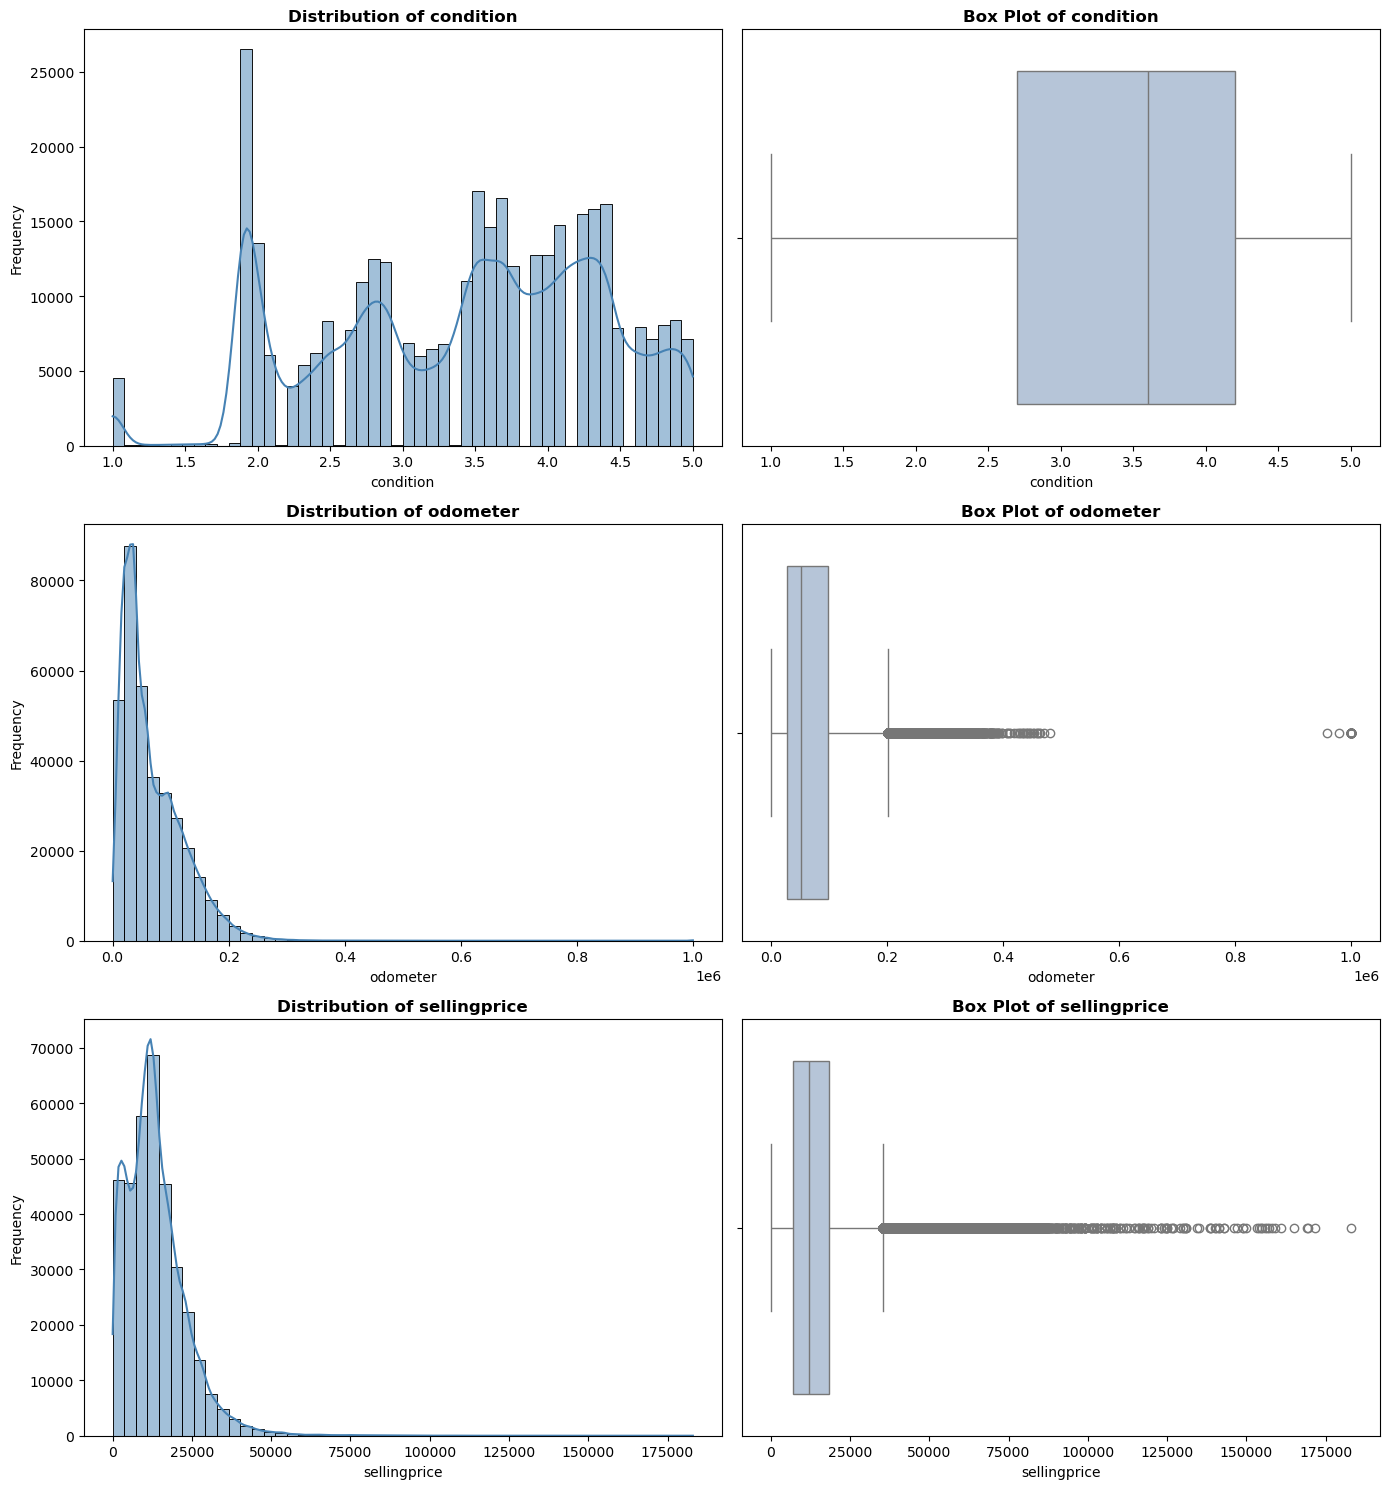

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['condition', 'odometer', 'sellingprice']

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=2, figsize=(14, 5 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    sns.histplot(data=train_df, x=col, kde=True, bins=50, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Frequency')
    
    sns.boxplot(data=train_df, x=col, ax=axes[i, 1], color='lightsteelblue')
    axes[i, 1].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

##### As calculated by the skewness and kurtosis, the sellingprice and odometer is right tailed, with and having some extreme outliers as predicted by the kurtosis

##### Using log transformed data for better IQR analysis

In [135]:
master_encoders['log_iqr_bounds'] = {}

print("--- Log-Transformed Outlier Bounds ---")

for col in ['sellingprice', 'odometer']:
    log_col = np.log1p(train_df[col])
    
    Q1 = log_col.quantile(0.25)
    Q3 = log_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = np.expm1(Q1 - 1.5 * IQR)
    upper = np.expm1(Q3 + 1.5 * IQR)
    
    if col != 'sellingprice':
        master_encoders['log_iqr_bounds'][col] = {'lower': lower, 'upper': upper}
    
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    outlier_pct = (len(outliers) / len(train_df)) * 100
    
    print(f"{col.upper()}:")
    print(f"  Bounds: Lower = {lower:.0f} | Upper = {upper:.0f}")
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.2f}%)\n")

--- Log-Transformed Outlier Bounds ---
SELLINGPRICE:
  Bounds: Lower = 1655 | Upper = 77347
  Outliers: 19319 (5.51%)

ODOMETER:
  Bounds: Lower = 4345 | Upper = 633821
  Outliers: 4850 (1.38%)



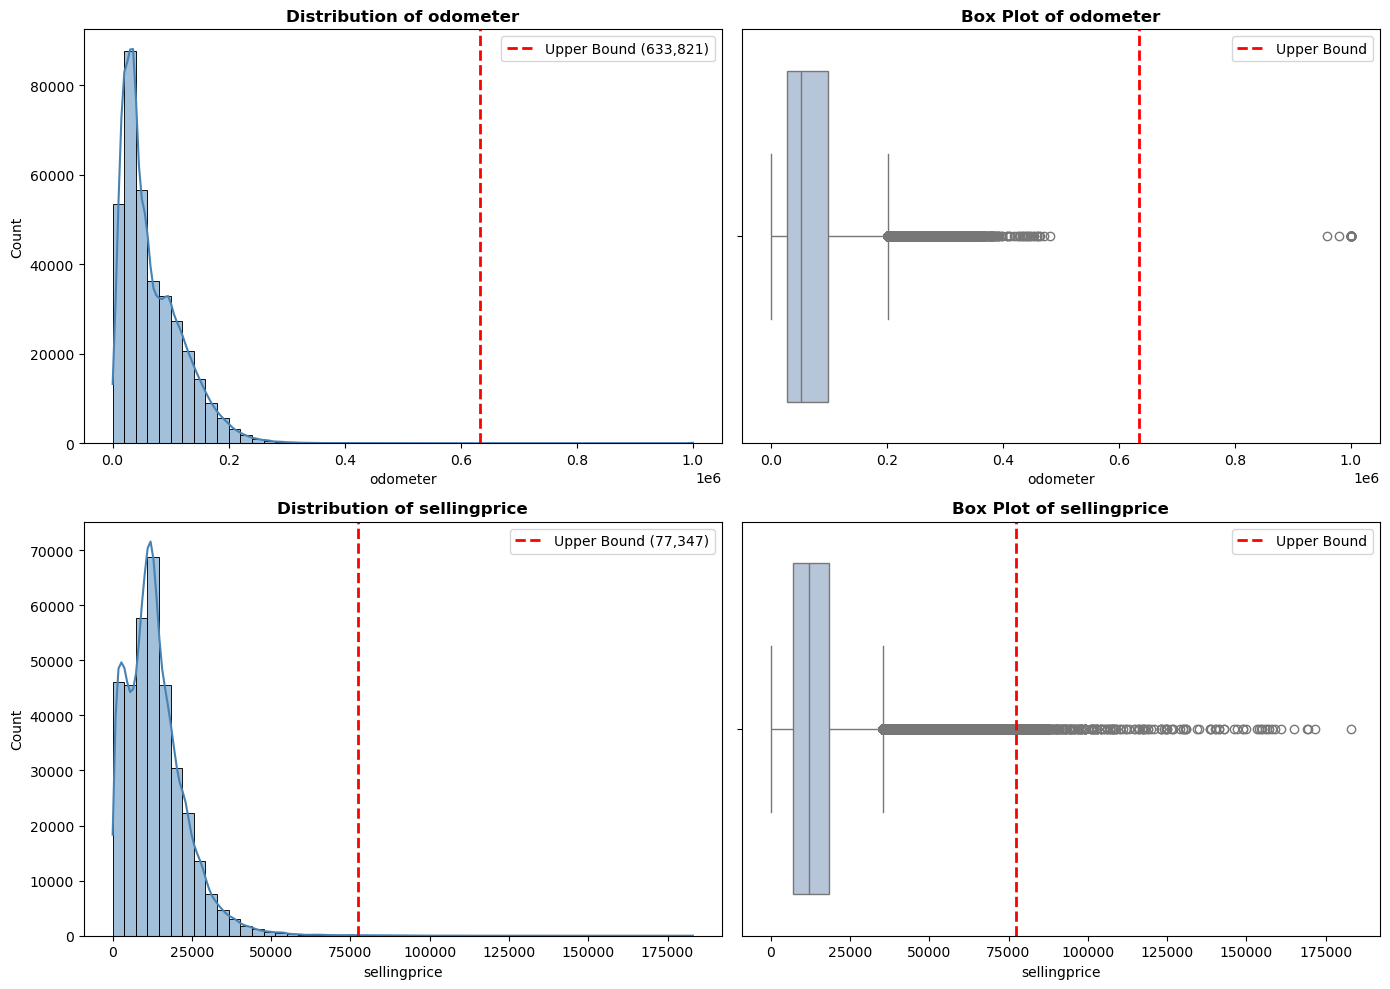

In [136]:
cols_to_plot = ['odometer', 'sellingprice']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

for i, col in enumerate(cols_to_plot):
    log_col = np.log1p(train_df[col])
    Q1 = log_col.quantile(0.25)
    Q3 = log_col.quantile(0.75)
    IQR = Q3 - Q1
    upper = np.expm1(Q3 + 1.5 * IQR)
    
    sns.histplot(data=train_df, x=col, kde=True, bins=50, ax=axes[i, 0], color='steelblue')
    axes[i, 0].axvline(upper, color='red', linestyle='--', linewidth=2, label=f'Upper Bound ({upper:,.0f})')
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i, 0].legend()
    
    sns.boxplot(data=train_df, x=col, ax=axes[i, 1], color='lightsteelblue')
    axes[i, 1].axvline(upper, color='red', linestyle='--', linewidth=2, label='Upper Bound')
    axes[i, 1].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

##### Now the question is "How can I deal with these outliers, how do I know if they are genuine cases or data entry error?"

In [137]:
log_price = np.log1p(train_df['sellingprice'])
Q1_price = log_price.quantile(0.25)
Q3_price = log_price.quantile(0.75)
IQR_price = Q3_price - Q1_price
price_lower = np.expm1(Q1_price - 1.5 * IQR_price)
price_upper = np.expm1(Q3_price + 1.5 * IQR_price)

print(f"--- High Price Outliers ( > ${price_upper:,.0f}) ---")
high_price_outliers = train_df[train_df['sellingprice'] > price_upper]
print("Top 10 Makes:")
print(high_price_outliers['make'].value_counts().head(10))
print("\nSummary Stats:")
print(high_price_outliers[['year', 'odometer', 'condition']].describe())

print(f"\n--- Low Price Outliers ( < ${price_lower:,.0f}) ---")
low_price_outliers = train_df[train_df['sellingprice'] < price_lower]
print("Top 10 Makes:")
print(low_price_outliers['make'].value_counts().head(10))
print("\nSummary Stats:")
print(low_price_outliers[['year', 'odometer', 'condition']].describe())

--- High Price Outliers ( > $77,347) ---
Top 10 Makes:
make
mercedes-benz    73
porsche          68
land rover       46
bmw              44
audi             29
nissan           21
bentley          17
jaguar           14
ferrari          11
rolls-royce      11
Name: count, dtype: int64

Summary Stats:
              year      odometer   condition
count   361.000000    361.000000  361.000000
mean   2013.138504  12150.155125    4.452355
std       1.680835  10385.264097    0.465163
min    2004.000000     22.000000    2.600000
25%    2013.000000   5256.000000    4.200000
50%    2014.000000   9411.000000    4.500000
75%    2014.000000  16049.000000    4.800000
max    2015.000000  82985.000000    5.000000

--- Low Price Outliers ( < $1,655) ---
Top 10 Makes:
make
ford         2986
chevrolet    2286
honda        1305
dodge        1122
nissan       1095
chrysler      984
toyota        934
pontiac       746
saturn        610
hyundai       608
Name: count, dtype: int64

Summary Stats:
            

##### This does gives a good idea, most of the sellingprice outliers at the right end, are genuine anamolies and cannot be discarded, similar can be said about the outliers at the left, with a few exceptions.

##### To clean the `odometer` column, we isolate and fix obvious data entry errors (`> 900,000` or `< 10` miles). We convert these specific errors to `NaN` and immediately recalculate them using a hierarchial imputer. 

We leave all genuine high-mileage outliers completely intact. We will handle the analysis of those extreme values later during the Feature Engineering phase.

In [138]:
error_mask_train = (train_df['odometer'] > 900000) | (train_df['odometer'] < 10)
error_mask_val = (val_df['odometer'] > 900000) | (val_df['odometer'] < 10)

print(f"Typos found and removed in Train: {error_mask_train.sum()}")

train_df.loc[error_mask_train, 'odometer'] = np.nan
val_df.loc[error_mask_val, 'odometer'] = np.nan

train_df['odometer'] = train_df.apply(lambda row: impute_hierarchical_numeric(row, master_encoders['odometer'], 'odometer'), axis=1)
val_df['odometer'] = val_df.apply(lambda row: impute_hierarchical_numeric(row, master_encoders['odometer'], 'odometer'), axis=1)

Typos found and removed in Train: 924


##### We End the data cleaning part with removing the duplicates if any

In [139]:
initial_len = len(train_df)
train_df = train_df.drop_duplicates()
print(f"Duplicates removed: {initial_len - len(train_df)}")

cat_cols = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']

for col in cat_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].astype(str).str.lower().str.strip()
        val_df[col] = val_df[col].astype(str).str.lower().str.strip()


Duplicates removed: 0


#### Lets now focus more on the EDA part 


#### Starting with BIVARIATE ANALYSIS

Because our numerical features (`odometer`, `sellingprice`) contain genuine extreme outliers and are not normally distributed, standard Pearson correlation is mathematically inappropriate. Instead, we use **Spearman Rank Correlation**, which evaluates the monotonic relationship between variables

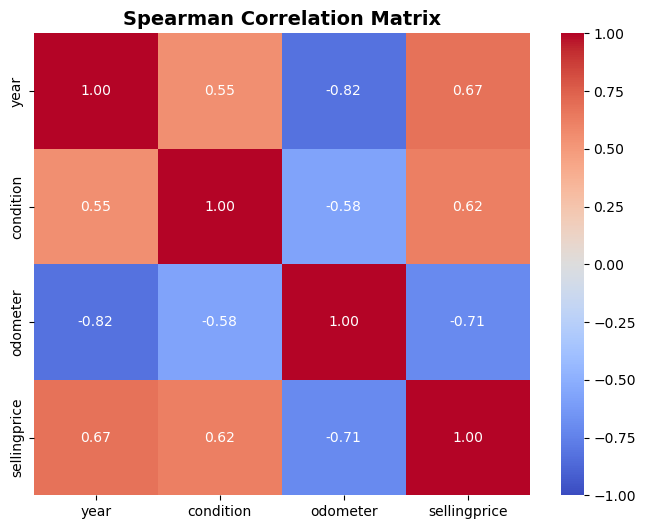

In [140]:
plt.figure(figsize=(8, 6))

numeric_cols = ['year', 'condition', 'odometer','sellingprice']

spearman_corr = train_df[numeric_cols].corr(method='spearman')

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

To determine which text columns drive the `sellingprice` the most, we calculate Mutual Information (MI) scores. MI measures the reduction in uncertainty for the target variable given a known feature.

In [141]:
from sklearn.feature_selection import mutual_info_regression

model           0.639495
trim            0.544987
make            0.201495
body            0.139869
state           0.101575
interior        0.049373
color           0.031551
transmission    0.002912
dtype: float64


/var/folders/jz/zx7z4fhj4s359p1n020g0kwm0000gn/T/ipykernel_31095/595322431.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_results.values, y=mi_results.index, palette='viridis')


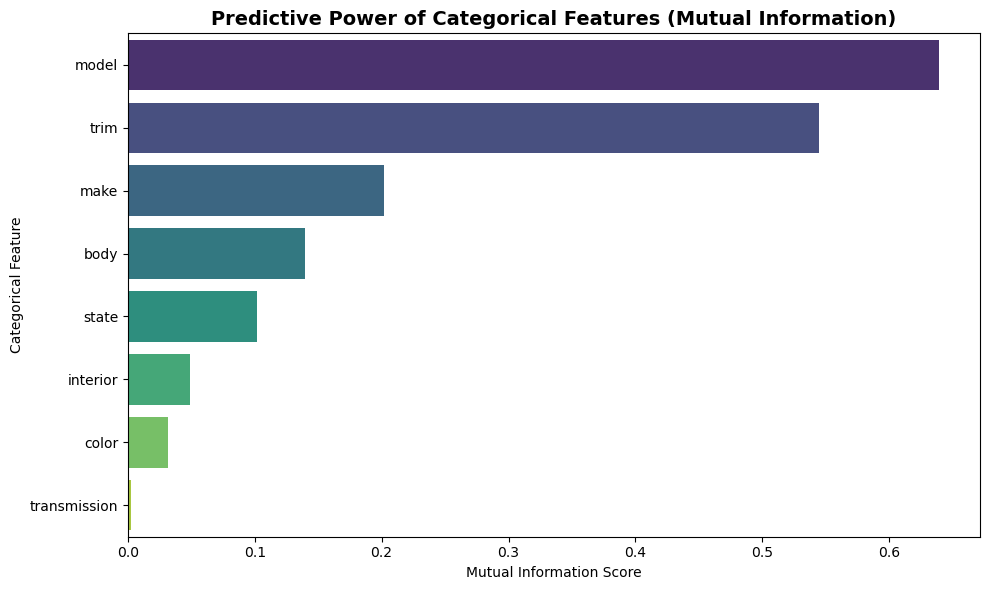

In [142]:
cat_cols = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']

mi_df = train_df[cat_cols].copy()
for col in cat_cols:
    mi_df[col], _ = pd.factorize(mi_df[col])

mi_scores = mutual_info_regression(mi_df, train_df['sellingprice'], discrete_features=True, random_state=42)

mi_results = pd.Series(mi_scores, index=cat_cols).sort_values(ascending=False)

print(mi_results)
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_results.values, y=mi_results.index, palette='viridis')
plt.title('Predictive Power of Categorical Features (Mutual Information)', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Categorical Feature')
plt.tight_layout()
plt.show()

We can see
interior        0.049373
color           0.031551
transmission    0.002912
have very low MI scores, 
before dropping them lets see if we can engineer some useful features from them or not, or are they genuinely useless.

Start with color part, are some colors more demanded

In [143]:
luxury = ['mercedes-benz', 'bmw', 'porsche', 'audi', 'bentley']

train_df['is_luxury'] = train_df['make'].isin(luxury).astype(int)

print("Color price impact — Luxury cars:")
print(train_df[train_df['is_luxury']==1].groupby('color')['sellingprice'].mean().sort_values(ascending=False).head(10))

print("\nColor price impact — Economy cars:")
print(train_df[train_df['is_luxury']==0].groupby('color')['sellingprice'].mean().sort_values(ascending=False).head(10))

Color price impact — Luxury cars:
color
orange       32654.166667
brown        29868.257261
yellow       27422.222222
white        25121.344060
charcoal     24125.000000
black        23826.806378
gray         22474.042479
red          21865.322581
off-white    20442.857143
blue         17764.038927
Name: sellingprice, dtype: float64

Color price impact — Economy cars:
color
charcoal     15956.208054
off-white    15418.844211
lime         15025.000000
brown        14801.681013
black        14762.828592
white        14197.181868
gray         13244.108036
orange       12827.970708
red          12506.277014
pink         12498.275862
Name: sellingprice, dtype: float64


In [227]:
sns.set_theme(style="whitegrid")

# 1. Compute aggregates and reset indices for Seaborn mapping
luxury_colors = (
    train_df[train_df['is_luxury'] == 1]
    .groupby('color')['sellingprice']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

economy_colors = (
    train_df[train_df['is_luxury'] == 0]
    .groupby('color')['sellingprice']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 2. Construct side-by-side subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# Plot Luxury Segment
sns.barplot(
    data=luxury_colors,
    x='sellingprice',
    y='color',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Color Price Impact — Luxury Cars (Top 10)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Mean Selling Price ($)', fontsize=11)
axes[0].set_ylabel('Vehicle Color', fontsize=11)

# Plot Economy Segment
sns.barplot(
    data=economy_colors,
    x='sellingprice',
    y='color',
    ax=axes[1],
    palette='Greens_r'
)
axes[1].set_title('Color Price Impact — Economy Cars (Top 10)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Mean Selling Price ($)', fontsize=11)
axes[1].set_ylabel('') # Omit label on the right subplot to reduce clutter

# 3. Precision Engineering: Add numeric labels to the end of each bar
for ax in axes:
    ax.set_axisbelow(True)  # Gridlines sit cleanly behind the bars
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='$%,.0f', 
            padding=6, 
            fontsize=9, 
            fontweight='semibold', 
            color='#333333'
        )

# Adjust spacing and display
plt.tight_layout()
plt.show()

KeyError: 'color'

Check the same for interior

In [144]:
print("Interior price impact — Luxury cars:")
print(train_df[train_df['is_luxury']==1].groupby('interior')['sellingprice'].mean().sort_values(ascending=False).head(10))

print("\nInterior price impact — Economy cars:")
print(train_df[train_df['is_luxury']==0].groupby('interior')['sellingprice'].mean().sort_values(ascending=False).head(10))

Interior price impact — Luxury cars:
interior
white        33425.000000
red          31813.978495
burgundy     29916.000000
off-white    29006.250000
brown        27072.856571
orange       24864.285714
black        23760.938829
purple       20032.608696
beige        19458.059701
blue         18998.529412
Name: sellingprice, dtype: float64

Interior price impact — Economy cars:
interior
off-white    25685.714286
red          20035.981697
brown        18810.701784
burgundy     18029.166667
orange       18027.702703
yellow       17253.846154
black        14777.832414
white        13821.942623
purple       13201.025641
beige        12686.719049
Name: sellingprice, dtype: float64


we engineer binary flags (`1` or `0`). By grouping specific luxury makes, exotic exterior colors, and premium interiors, we create highly robust signals. 

Crucially, we create an interaction flag (`luxury_exotic_color`) that allows the machine learning model to explicitly recognize the massive price premium these colors command *only* when applied to high-end vehicles.

In [145]:
luxury_makes = ['mercedes-benz', 'bmw', 'porsche', 'audi', 
                'bentley', 'ferrari', 'rolls-royce', 'jaguar', 
                'land rover', 'lexus', 'maserati']

exotic_colors = ['orange', 'yellow', 'brown', 'purple', 'lime']

premium_interiors = ['white', 'red', 'burgundy', 'off-white']

def engineer_binary_flags(df):
    df['is_luxury'] = df['make'].isin(luxury_makes).astype(int)
    df['has_exotic_color'] = df['color'].isin(exotic_colors).astype(int)
    df['has_premium_interior'] = df['interior'].isin(premium_interiors).astype(int)
    
    df['luxury_exotic_color'] = (df['is_luxury'] & df['has_exotic_color']).astype(int)
    df['luxury_premium_interior'] = (df['is_luxury'] & df['has_premium_interior']).astype(int)
    
    return df

train_df = engineer_binary_flags(train_df)
val_df = engineer_binary_flags(val_df)

# Since we extracted the value from color and interior, we can safely drop them now
cols_to_drop = ['color', 'interior']
train_df = train_df.drop(columns=[col for col in cols_to_drop if col in train_df.columns])
val_df = val_df.drop(columns=[col for col in cols_to_drop if col in val_df.columns])

To fulfill our EDA requirements, we engineer `car_age` and `usage_intensity` (miles driven per year). Because we lack a reliable `saledate` column, we use a static `reference_year` based on the newest car in the training dataset to ensure realistic age calculations.

In [146]:
reference_year = train_df['year'].max()+ 1 # added 1 to take in account that there might be buffer time between auction time and year

train_df['car_age'] = np.maximum(reference_year - train_df['year'], 1)
val_df['car_age'] = np.maximum(reference_year - val_df['year'], 1)

train_df['usage_intensity'] = train_df['odometer'] / train_df['car_age']
val_df['usage_intensity'] = val_df['odometer'] / val_df['car_age']


In [147]:
train_df.sample(5)

,year,make,model,trim,body,transmission,state,condition,odometer,sellingprice,transmission_missing,is_luxury,has_exotic_color,has_premium_interior,luxury_exotic_color,luxury_premium_interior,car_age,usage_intensity
228790,2011,toyota,highlander,base,suv,automatic,tn,3.9,45531.0,21500,0,0,0,0,0,0,5,9106.200000
25772,2011,mitsubishi,outlander sport,es,suv,automatic,fl,4.1,37682.0,10600,0,0,0,0,0,0,5,7536.400000
164865,2012,honda,crosstour,ex-l,hatchback,automatic,il,2.9,33391.0,12700,0,0,0,0,0,0,4,8347.750000
420157,2014,ford,escape,titanium,suv,automatic,il,3.7,25828.0,22900,0,0,0,0,0,0,2,12914.000000
184427,2013,hyundai,sonata,gls,sedan,automatic,oh,3.7,35020.0,12200,0,0,0,0,0,0,3,11673.333333


#### EDA: Depreciation Curves by Body Type
We visualize how the `sellingprice` decays over time (`year`) for the top 5 most common vehicle body types. This helps us understand if certain vehicle classes (like SUVs or Trucks) depreciate at different, non-linear rates compared to standard commuter cars.

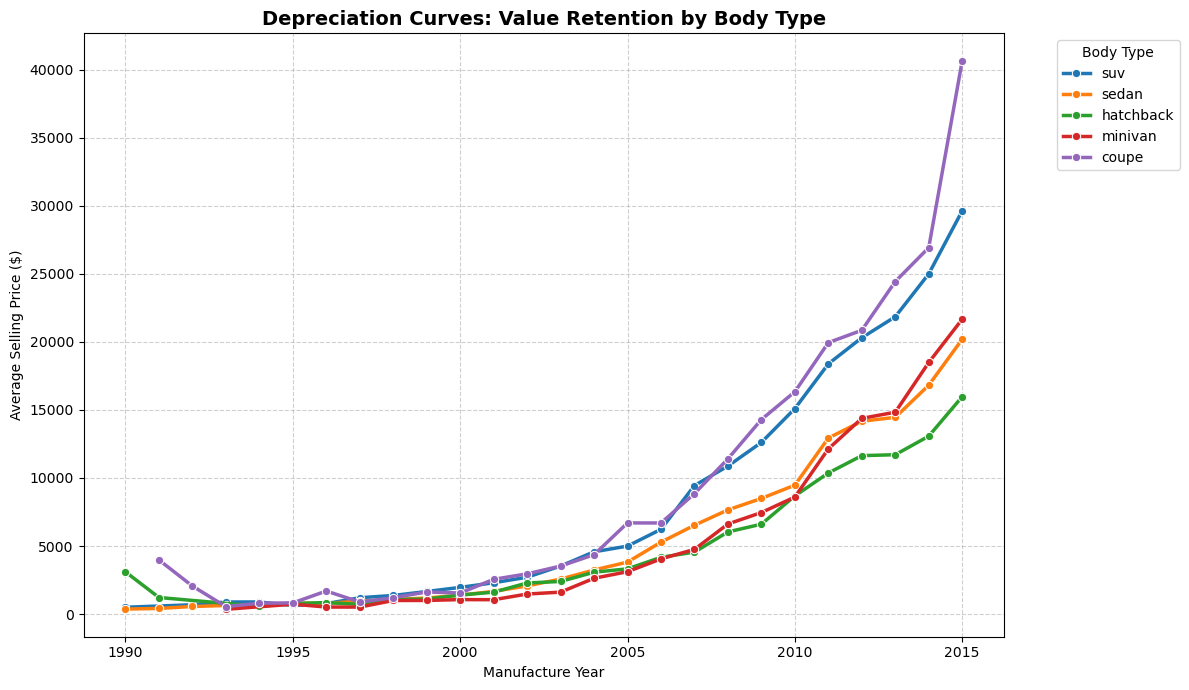

In [148]:
# 1. Get the top 5 most common body types
top_bodies = train_df['body'].value_counts().nlargest(5).index
depreciation_df = train_df[train_df['body'].isin(top_bodies)]

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=depreciation_df, 
    x='year', 
    y='sellingprice', 
    hue='body', 
    marker='o',
    linewidth=2.5,
    errorbar=None 
)

# 3. Formatting
plt.title('Depreciation Curves: Value Retention by Body Type', fontsize=14, fontweight='bold')
plt.xlabel('Manufacture Year')
plt.ylabel('Average Selling Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Body Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Few Insights that can be observed (except the obvious ones)
1. In the very left you can the five lines merge together into a flat, horizontal line near $1,000 - $2,000.The data tells us ,Once a car is 15+ years old, the body type no longer matters. A 1995 SUV and a 1995 Sedan are both just cheap scrap metal.
2. The data proves that cars do not lose a flat $2,000 a year; they lose massive percentages of their value immediately, and then the depreciation slows down as the car gets older.

Condition Non-Linearity via LOWESS

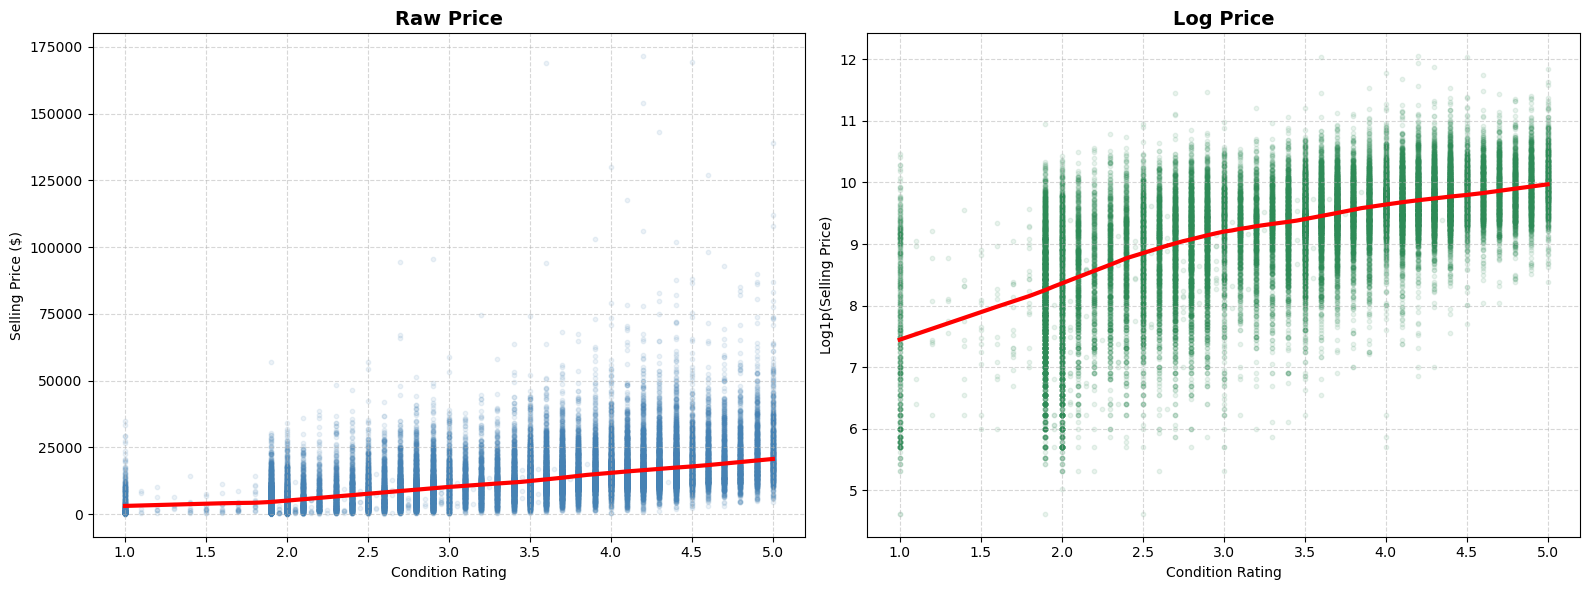

In [149]:
import statsmodels.api as sm

sample = train_df.sample(frac=0.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

smoothed_raw = sm.nonparametric.lowess(sample['sellingprice'], sample['condition'], frac=0.3)

axes[0].scatter(sample['condition'], sample['sellingprice'], alpha=0.1, color='steelblue', s=10)
axes[0].plot(smoothed_raw[:, 0], smoothed_raw[:, 1], 'r-', linewidth=3)
axes[0].set_title('Raw Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Condition Rating')
axes[0].set_ylabel('Selling Price ($)')
axes[0].grid(True, linestyle='--', alpha=0.5)

smoothed_log = sm.nonparametric.lowess(np.log1p(sample['sellingprice']), sample['condition'], frac=0.3)

axes[1].scatter(sample['condition'], np.log1p(sample['sellingprice']), alpha=0.1, color='seagreen', s=10)
axes[1].plot(smoothed_log[:, 0], smoothed_log[:, 1], 'r-', linewidth=3)
axes[1].set_title('Log Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Condition Rating')
axes[1].set_ylabel('Log1p(Selling Price)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

We can observe that in raw price, the slope is low and constant almost till condition<2, after which it becomes steep, also the spread in the left is less than 25000$, this increases alot as we go right i.e as the condition rating gets larger, in raw price, The LOWESS curve is being dragged down by the massive volume of cheap cars it's not showing us the full story.

In the log price, steep rise in 1 to 2, in 2 to 3 this kind of continues, but it starts to flatten noticebally, this tells us that proportional price gains are largest in the 1.0 to 3.0 range, not at the top end. Going from condition 2 to 3 gives us a bigger proportional jump than going from condition 4 to 5.

Till condition < 2, since the spread is low and prices low, tells us that they are not the main retail candidates irrespective of the make and model, while after 3 it seems like the other factors also start taking over the cars price 

To verify our finding statistically, lets compute something called the coefficient of variance = std/mean

=== Condition Band Analysis ===
                mean   median       std    cv  mean_change  pct_change
condition                                                             
(1.0, 1.5]   3703.57   2500.0   3410.60  0.92          NaN         NaN
(1.5, 2.0]   5251.28   3600.0   5121.21  0.98      1547.71       41.79
(2.0, 2.5]   7853.82   6300.0   6323.18  0.81      2602.54       49.56
(2.5, 3.0]  10249.32   9000.0   7148.15  0.70      2395.50       30.50
(3.0, 3.5]  12671.17  11400.0   7481.26  0.59      2421.86       23.63
(3.5, 4.0]  15558.71  13900.0   8228.26  0.53      2887.54       22.79
(4.0, 4.5]  18482.99  16400.0   9481.15  0.51      2924.28       18.80
(4.5, 5.0]  22095.48  19800.0  11192.93  0.51      3612.49       19.54


/var/folders/jz/zx7z4fhj4s359p1n020g0kwm0000gn/T/ipykernel_31095/2355982149.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_stats = train_df.groupby(bands)['sellingprice'].agg(['mean', 'median', 'std'])


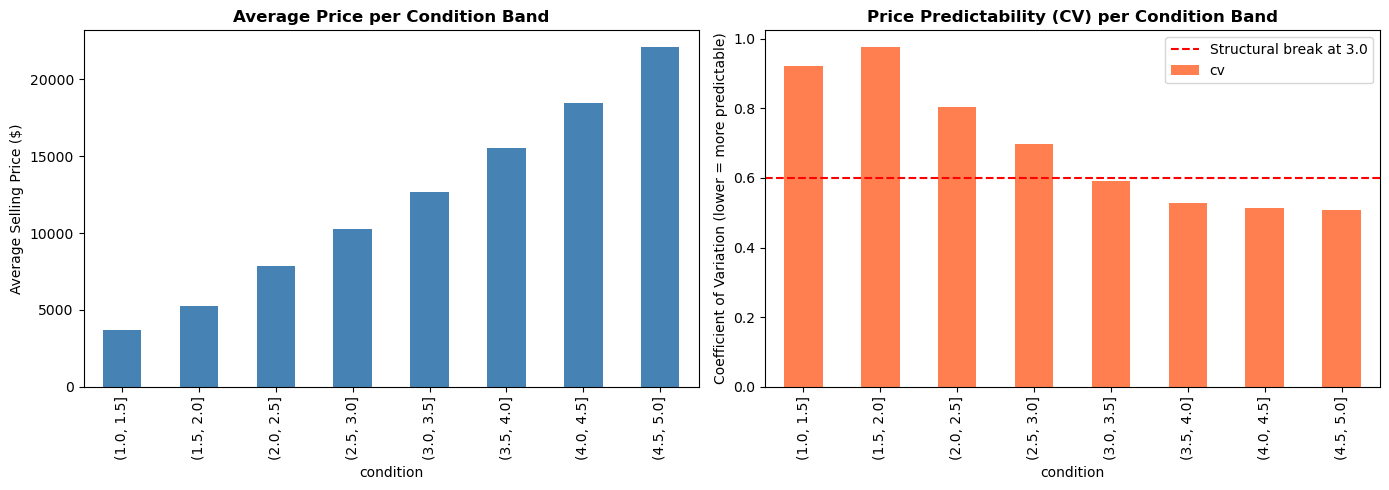

In [150]:
#let's find exactly where 
# the rate of price change is largest

bands = pd.cut(train_df['condition'], bins=np.arange(1, 5.5, 0.5))
band_stats = train_df.groupby(bands)['sellingprice'].agg(['mean', 'median', 'std'])
band_stats['cv'] = band_stats['std'] / band_stats['mean']
band_stats['mean_change'] = band_stats['mean'].diff()
band_stats['pct_change'] = band_stats['mean'].pct_change() * 100

print("=== Condition Band Analysis ===")
print(band_stats.round(2))

# Visualize the rate of change
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_stats['mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Price per Condition Band', fontweight='bold')
axes[0].set_ylabel('Average Selling Price ($)')

band_stats['cv'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Price Predictability (CV) per Condition Band', fontweight='bold')
axes[1].set_ylabel('Coefficient of Variation (lower = more predictable)')
axes[1].axhline(y=0.6, color='red', linestyle='--', label='Structural break at 3.0')
axes[1].legend()

plt.tight_layout()
plt.show()

In [151]:
# Calculate average price and rate of change per condition band
bands = pd.cut(train_df['condition'], bins=np.arange(1, 5.5, 0.5))
band_stats = train_df.groupby(bands)['sellingprice'].agg(['mean', 'median', 'std'])

# Rate of change between bands
band_stats['mean_change'] = band_stats['mean'].diff()
band_stats['pct_change'] = band_stats['mean'].pct_change() * 100

band_stats.round(0)

/var/folders/jz/zx7z4fhj4s359p1n020g0kwm0000gn/T/ipykernel_31095/438775033.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_stats = train_df.groupby(bands)['sellingprice'].agg(['mean', 'median', 'std'])


,mean,median,std,mean_change,pct_change
condition,,,,,
"(1.0, 1.5]",3704.0,2500.0,3411.0,NaN,NaN
"(1.5, 2.0]",5251.0,3600.0,5121.0,1548.0,42.0
"(2.0, 2.5]",7854.0,6300.0,6323.0,2603.0,50.0
"(2.5, 3.0]",10249.0,9000.0,7148.0,2396.0,31.0
"(3.0, 3.5]",12671.0,11400.0,7481.0,2422.0,24.0
"(3.5, 4.0]",15559.0,13900.0,8228.0,2888.0,23.0
"(4.0, 4.5]",18483.0,16400.0,9481.0,2924.0,19.0
"(4.5, 5.0]",22095.0,19800.0,11193.0,3612.0,20.0


In [152]:
band_stats['cv'] = band_stats['std'] / band_stats['mean']
band_stats['cv']

condition
(1.0, 1.5]    0.920895
(1.5, 2.0]    0.975231
(2.0, 2.5]    0.805109
(2.5, 3.0]    0.697427
(3.0, 3.5]    0.590416
(3.5, 4.0]    0.528852
(4.0, 4.5]    0.512966
(4.5, 5.0]    0.506571
Name: cv, dtype: float64

Better condition cars are MORE predictably priced, this is evident by the cv value , that is lowest for high condition rating car, and seens to plateaus as we reach better rating

#### Transmission x body type interaction

In [153]:
train_df['transmission'].value_counts(normalize=True)

transmission
automatic    0.968966
manual       0.031034
Name: proportion, dtype: float64

In [154]:
# Count rows per combination
counts = train_df.groupby(['transmission', 'body']).size().unstack()
print("=== Row Counts Per Combination ===")
print(counts)

# Flag combinations with less than 100 rows
print("\n=== Combinations with < 100 rows (unreliable) ===")
print(counts[counts < 100])

=== Row Counts Per Combination ===
body          access cab  beetle convertible  cab plus  cab plus 4  club cab  \
transmission                                                                   
automatic          158.0                40.0       NaN         NaN     103.0   
manual              29.0                 1.0       1.0         2.0       7.0   

body          convertible   coupe  crew cab  crewmax cab  cts coupe  ...  \
transmission                                                         ...   
automatic          5992.0  9406.0   10456.0        347.0      102.0  ...   
manual              734.0  2022.0      72.0          NaN        NaN  ...   

body          regular-cab     sedan  supercab  supercrew      suv  \
transmission                                                        
automatic            11.0  151746.0    3266.0     5896.0  91173.0   
manual                NaN    3479.0     129.0        1.0   1217.0   

body          transit van  tsx sport wagon     van    wagon  x

#### One more thing, I think i missed, is that there are 45 unique body types, and most of them are similar, like crew cab, access cab, cab plus are all just pickup trucks, we can categorize them better

In [155]:
body_mapping = {
    # Pickups
    'access cab': 'pickup',
    'cab plus': 'pickup', 
    'cab plus 4': 'pickup',
    'club cab': 'pickup',
    'crew cab': 'pickup',
    'crewmax cab': 'pickup',
    'regular-cab': 'pickup',
    'supercab': 'pickup',
    'supercrew': 'pickup',
    'xtracab': 'pickup',
    
    # Vans
    'van': 'van',
    'transit van': 'van',
    'minivan': 'van',
    
    # Coupes
    'coupe': 'coupe',
    'cts coupe': 'coupe',
    'beetle convertible': 'convertible',
    'tsx sport wagon': 'wagon',
    
    # Keep as-is
    'sedan': 'sedan',
    'suv': 'suv',
    'convertible': 'convertible',
    'hatchback': 'hatchback',
    'wagon': 'wagon'
}

train_df['body_clean'] = train_df['body'].str.lower().map(body_mapping).fillna('other')
val_df['body_clean'] = val_df['body'].str.lower().map(body_mapping).fillna('other')

train_df['body_clean'].value_counts()

body_clean
sedan          155225
suv             92390
pickup          20511
van             19294
other           17664
hatchback       16713
coupe           11530
wagon           10620
convertible      6767
Name: count, dtype: int64

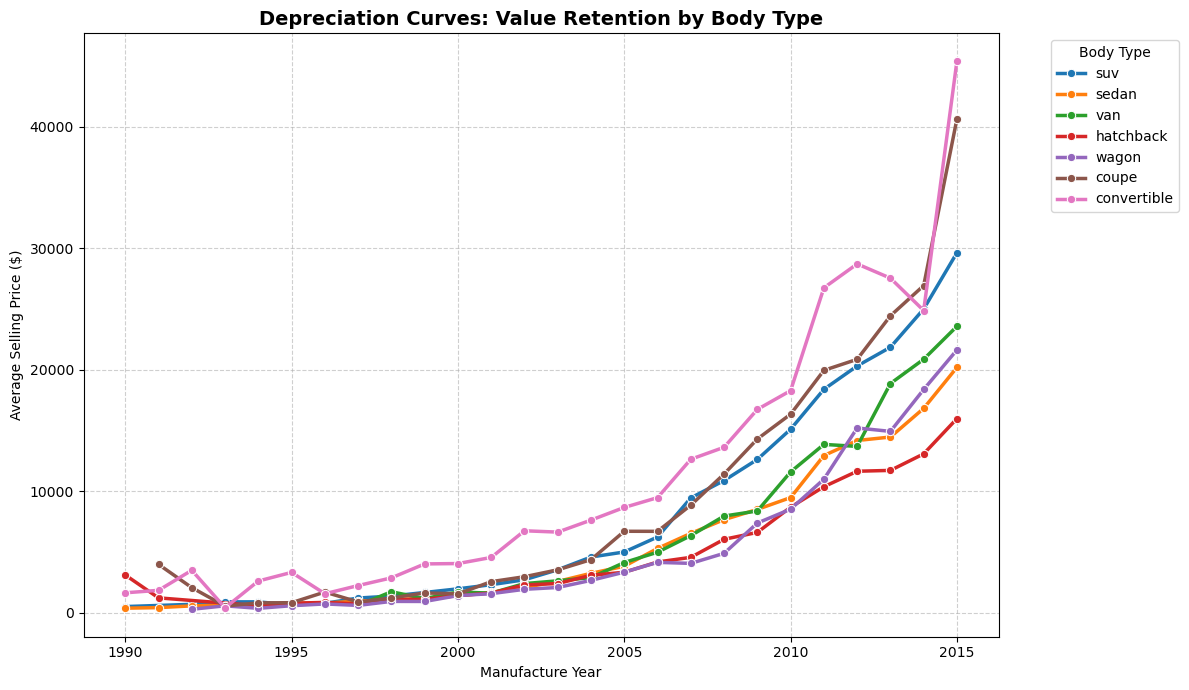

In [156]:
# 1. Get the top 5 most common body types
top_bodies = train_df['body_clean'].value_counts().nlargest(9).index
depreciation_df = train_df[train_df['body'].isin(top_bodies)]

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=depreciation_df, 
    x='year', 
    y='sellingprice', 
    hue='body', 
    marker='o',
    linewidth=2.5,
    errorbar=None 
)

# 3. Formatting
plt.title('Depreciation Curves: Value Retention by Body Type', fontsize=14, fontweight='bold')
plt.xlabel('Manufacture Year')
plt.ylabel('Average Selling Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Body Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### What this tells us beyond the obvious:
##### 1. Coupes show the steepest VALUE RETENTION curve post-2010 — 
#####    not because coupes got better, but because the MIX of coupes 
#####    shifted toward luxury/sports vehicles. This is a composition effect.
#####
##### 2. Pickups retain value surprisingly well in the 2000-2010 range,
#####    outperforming sedans proportionally — suggesting commercial demand 
#####    keeps truck prices more stable than purely consumer-driven segments.
#####
##### 3. The convergence below 1999 is now quantified — all body types 
#####    retain less than 15% of their 2015 equivalent value, confirming 
#####    that body type loses predictive power for pre-2000 vehicles.
#####
##### Implication for the model: a year × body_clean interaction term 
##### would help capture this era-dependent behavior.

In [157]:
counts = train_df.groupby(['transmission', 'body_clean']).size().unstack()
print("=== Clean Row Counts ===")
print(counts)

pivot = train_df.groupby(
    ['transmission', 'body_clean']
)['sellingprice'].mean().unstack()

body_avg = train_df.groupby('body_clean')['sellingprice'].mean()
deviation = pivot.subtract(body_avg, axis=1)

print("\n=== Deviation From Body Average ===")
print(deviation.round(0))

=== Clean Row Counts ===
body_clean    convertible  coupe  hatchback  other  pickup   sedan    suv  \
transmission                                                                
automatic            6032   9508      14642  17097   20267  151746  91173   
manual                735   2022       2071    567     244    3479   1217   

body_clean      van  wagon  
transmission                
automatic     19290  10075  
manual            4    545  

=== Deviation From Body Average ===
body_clean    convertible   coupe  hatchback   other  pickup   sedan     suv  \
transmission                                                                   
automatic           310.0  -273.0      173.0   153.0    87.0    84.0    30.0   
manual            -2542.0  1282.0    -1221.0 -4611.0 -7231.0 -3651.0 -2247.0   

body_clean       van   wagon  
transmission                  
automatic        1.0   131.0  
manual       -3783.0 -2428.0  


Text(0.5, 1.0, 'Price Deviation from Body Average by Transmission Type')

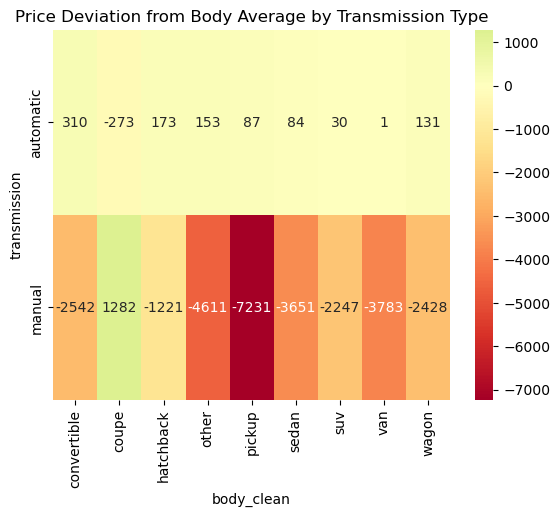

In [158]:
sns.heatmap(deviation.round(0), annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Price Deviation from Body Average by Transmission Type')

<Axes: title={'center': 'Transmission Class Imbalance'}, xlabel='transmission'>

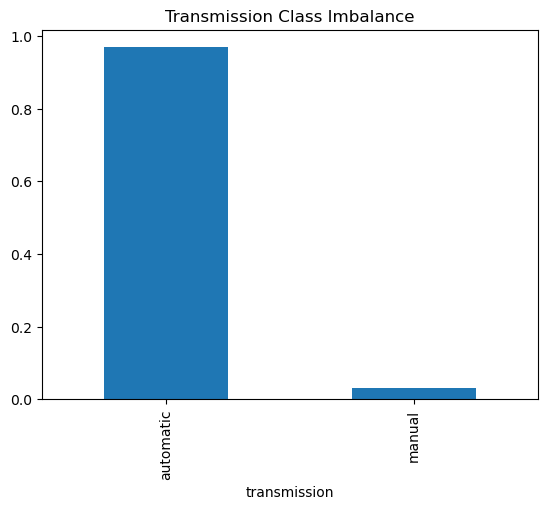

In [159]:
train_df['transmission'].value_counts(normalize=True).plot(
    kind='bar', title='Transmission Class Imbalance'
)

=== Price Deviation From Body Average ===
body_clean    convertible   coupe  hatchback   other  pickup   sedan     suv  \
transmission                                                                   
automatic           310.0  -273.0      173.0   153.0    87.0    84.0    30.0   
manual            -2542.0  1282.0    -1221.0 -4611.0 -7231.0 -3651.0 -2247.0   

body_clean       van   wagon  
transmission                  
automatic        1.0   131.0  
manual       -3783.0 -2428.0  

=== Row Counts (reliability check) ===
body_clean    convertible  coupe  hatchback  other  pickup   sedan    suv  \
transmission                                                                
automatic            6032   9508      14642  17097   20267  151746  91173   
manual                735   2022       2071    567     244    3479   1217   

body_clean      van  wagon  
transmission                
automatic     19290  10075  
manual            4    545  


<Figure size 1200x500 with 0 Axes>

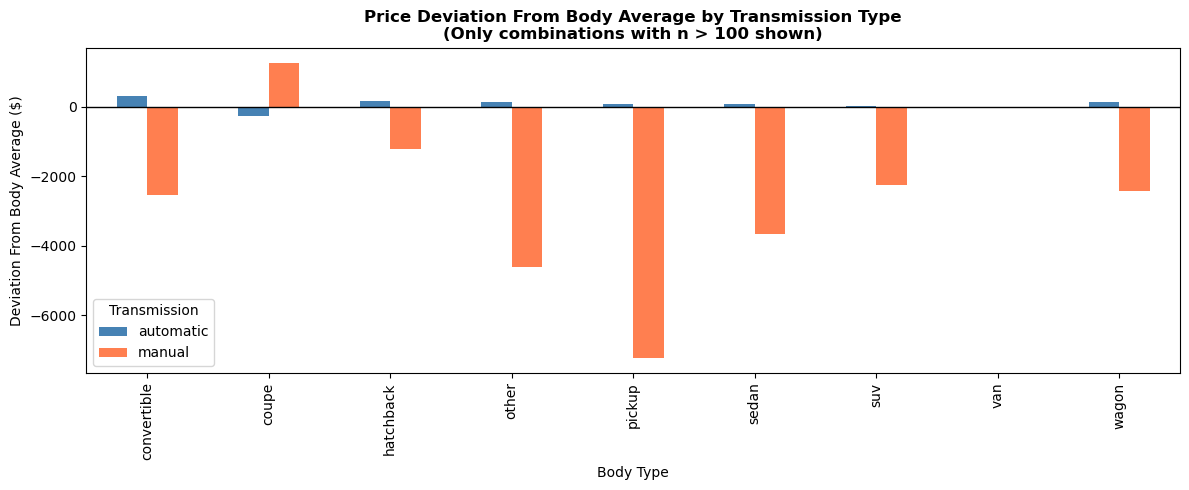

In [160]:
pivot = train_df.groupby(['transmission', 'body_clean'])['sellingprice'].mean().unstack()
counts = train_df.groupby(['transmission', 'body_clean']).size().unstack()
body_avg = train_df.groupby('body_clean')['sellingprice'].mean()
deviation = pivot.subtract(body_avg, axis=1)

print("=== Price Deviation From Body Average ===")
print(deviation.round(0))
print("\n=== Row Counts (reliability check) ===")
print(counts)

# Visualize only reliable combinations (n > 100)
reliable_mask = counts > 100
reliable_deviation = deviation[reliable_mask]

plt.figure(figsize=(12, 5))
reliable_deviation.T.plot(kind='bar', figsize=(12, 5), 
                           color=['steelblue', 'coral'])
plt.title('Price Deviation From Body Average by Transmission Type\n(Only combinations with n > 100 shown)', 
          fontweight='bold')
plt.xlabel('Body Type')
plt.ylabel('Deviation From Body Average ($)')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend(title='Transmission')
plt.tight_layout()
plt.show()

#### The ratio of data for automatic to manual is really high, this is not good, as our model might not have enough data to learn better to price manual cars, also the variation in price from average is evidently high in the manual cars

In [161]:
features_to_compare = ['odometer', 'year', 'car_age', 'usage_intensity']

mi_scores = mutual_info_regression(
    train_df[features_to_compare].dropna(),
    train_df.loc[train_df[features_to_compare].dropna().index, 'sellingprice'],
    random_state=42
)

mi_df = pd.DataFrame({
    'feature': features_to_compare,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

mi_df 

,feature,mi_score
1,year,0.452950
2,car_age,0.449062
0,odometer,0.420404
3,usage_intensity,0.065554


#### Usage intensity is far weaker than either of its component features individually. This is the opposite of what we hypothesized earlier.

##### Possible reason: is that we fail in examples like when car has 100 miles in 1 year, and other car has 10,000 miles in 10 years, the usage intensity parameter views them the same, but its obvious a car with only 1 year will be more priced than a car that is 10 years old.


##### Also car_age and year have basically same mi scores, as they are the same thing 

##### Before removing usage_intensity and car_age, lets also check their spearman correlation

In [162]:
corr, _ = spearmanr(train_df['year'], train_df['car_age'])
print(f"Spearman correlation between year and car_age: {corr:.4f}")

Spearman correlation between year and car_age: -1.0000


car_age and year carry identical information just expressed in opposite directions. Keeping both is completely redundant.

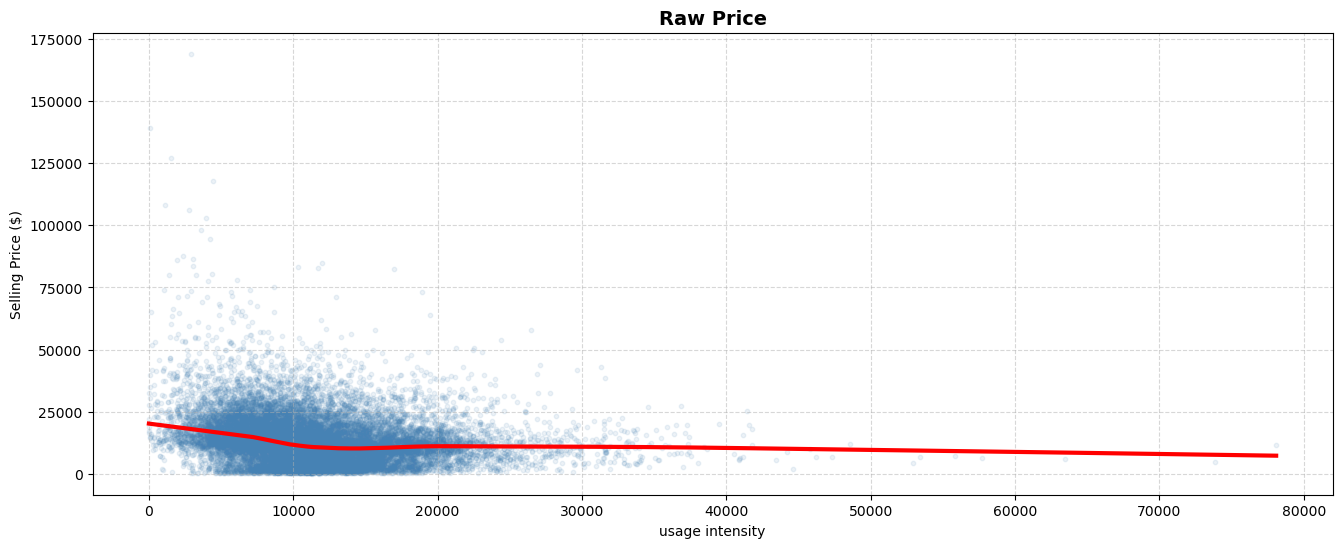

In [163]:
sample = train_df.sample(frac=0.05, random_state=42)

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

smoothed_raw = sm.nonparametric.lowess(sample['sellingprice'], sample['usage_intensity'], frac=0.3)

axes.scatter(sample['usage_intensity'], sample['sellingprice'], alpha=0.1, color='steelblue', s=10)
axes.plot(smoothed_raw[:, 0], smoothed_raw[:, 1], 'r-', linewidth=3)
axes.set_title('Raw Price', fontsize=14, fontweight='bold')
axes.set_xlabel('usage intensity')
axes.set_ylabel('Selling Price ($)')
axes.grid(True, linestyle='--', alpha=0.5)

The LOWESS curve at the left end is being anchored down by the mass of cheap old cars with low mileage, masking the high-value cluster entirely.

In [164]:
train_df.drop(columns=['car_age','usage_intensity'], inplace=True)
val_df.drop(columns=['car_age','usage_intensity'], inplace=True)


In [165]:
list(train_df.columns)

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'state',
 'condition',
 'odometer',
 'sellingprice',
 'transmission_missing',
 'is_luxury',
 'has_exotic_color',
 'has_premium_interior',
 'luxury_exotic_color',
 'luxury_premium_interior',
 'body_clean']

In [166]:
train_df.sample(5)

,year,make,model,trim,body,transmission,state,condition,odometer,sellingprice,transmission_missing,is_luxury,has_exotic_color,has_premium_interior,luxury_exotic_color,luxury_premium_interior,body_clean
107834,2013,honda,civic,si,sedan,manual,fl,3.9,41814.0,15000,0,0,0,0,0,0,sedan
238070,2009,ford,f-150,xl,supercrew,automatic,ca,3.4,84598.0,16500,0,0,0,0,0,0,pickup
328662,2014,chevrolet,cruze,1lt,sedan,automatic,fl,4.0,16900.0,12800,0,0,0,0,0,0,sedan
249248,2006,infiniti,g35,base,sedan,automatic,ut,2.0,100799.0,7100,0,0,0,0,0,0,sedan
59896,2005,honda,civic,lx,sedan,automatic,ma,1.9,106729.0,3300,0,0,0,0,0,0,sedan


In [167]:
cols_to_drop = ['transmission_missing', 'body']
train_df = train_df.drop(columns=[col for col in cols_to_drop if col in train_df.columns])
val_df = val_df.drop(columns=[col for col in cols_to_drop if col in val_df.columns])

### Encoding Strat

1. **Target Encoding (High Cardinality):** `make`, `model`, `trim`, and `state`. Unseen categories in the validation set fallback to the global mean.
2. **One-Hot Encoding (Low Cardinality):** `transmission` and `body_clean`. Because these have very few unique values, we safely expand them into binary flags.

In [168]:


target_cols = ['make', 'model', 'trim', 'state']

te = TargetEncoder(cols=target_cols, smoothing=10.0)

train_df[target_cols] = te.fit_transform(train_df[target_cols], train_df['sellingprice'])
val_df[target_cols] = te.transform(val_df[target_cols])

master_encoders['target_encoder'] = te

print(f"Target Encoded (with smoothing): {target_cols}")

ohe_cols = ['transmission', 'body_clean']

train_df = pd.get_dummies(train_df, columns=ohe_cols, drop_first=True, dtype=int)
val_df = pd.get_dummies(val_df, columns=ohe_cols, drop_first=True, dtype=int)

val_df = val_df.reindex(columns=train_df.columns, fill_value=0)

print("One-Hot Encoded: transmission, body_clean")
print("\nEncoding Complete! All data is now fully numerical.")
print(f"Final Training Data Shape: {train_df.shape}")

Target Encoded (with smoothing): ['make', 'model', 'trim', 'state']
One-Hot Encoded: transmission, body_clean

Encoding Complete! All data is now fully numerical.
Final Training Data Shape: (350714, 22)


# Modelling and Tuning

splitting data

In [169]:
feature_cols = [col for col in train_df.columns if col != 'sellingprice']

X_train = train_df[feature_cols]
y_train = train_df['sellingprice']

X_val = val_df[feature_cols]
y_val = val_df['sellingprice']

In [170]:
baseline_model = LGBMRegressor(random_state=42, verbose=-1)
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_val)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_preds))

print(f"Baseline (Default) RMSE: ${baseline_rmse:,.2f}")

Baseline (Default) RMSE: $2,669.39


In [171]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     param = {
#         'objective': 'regression',
#         'metric': 'rmse',
#         'verbose': -1,
#         'random_state': 42,
#         'n_jobs': -1,
        
#         # Tree structure
#         'num_leaves': trial.suggest_int('num_leaves', 20, 300),
#         'max_depth': trial.suggest_int('max_depth', 4, 12),
#         'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        
#         # Learning
#         'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        
#         # Sampling
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
#         # Regularization
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
#     }
    
#     # Inner split for early stopping
#     X_tr, X_es, y_tr, y_es = train_test_split(
#         X_train, y_train, test_size=0.1, random_state=42
#     )
    
#     model = LGBMRegressor(**param)
#     model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_es, y_es)],
#         callbacks=[early_stopping(50), log_evaluation(-1)]
#     )
    
#     preds = model.predict(X_es)
#     return np.sqrt(mean_squared_error(y_es, preds))

# study = optuna.create_study(
#     direction='minimize',
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=20)
# )

# study.optimize(objective, n_trials=100, show_progress_bar=True)

# best_lgb_params = study.best_params
# print(f"\nBest Optuna RMSE: ${study.best_value:,.2f}")
# print("Best Parameters:")
# for k, v in best_lgb_params.items():
#     print(f"  {k}: {v}")

In [172]:
final_model = LGBMRegressor(
    # --- Best parameters found by Optuna (100 trials) ---
    num_leaves        = 267,
    max_depth         = 12,
    min_child_samples = 20,
    n_estimators      = 2695,
    learning_rate     = 0.04448520618902436,
    subsample         = 0.6608213156946035,
    colsample_bytree  = 0.559848480331835,
    reg_alpha         = 7.828876699074059e-08,
    reg_lambda        = 0.6738162264732128,
    min_split_gain    = 0.032951951004890505,
    # --- Fixed params ---
    objective         = 'regression',
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

final_model.fit(X_train, y_train)

tuned_preds = final_model.predict(X_val)
tuned_rmse = np.sqrt(mean_squared_error(y_val, tuned_preds))

print(f"Baseline RMSE : ${baseline_rmse:,.2f}")
print(f"Tuned RMSE    : ${tuned_rmse:,.2f}")
print(f"Improvement   : ${baseline_rmse - tuned_rmse:,.2f} ({((baseline_rmse - tuned_rmse)/baseline_rmse)*100:.1f}%)")

Baseline RMSE : $2,669.39
Tuned RMSE    : $1,841.91
Improvement   : $827.48 (31.0%)


In [173]:
RUN_OPTUNA = False

if RUN_OPTUNA:
    optuna.visualization.plot_param_importances(study).show()
    optuna.visualization.plot_optimization_history(study).show()
else:
    print("Optuna visualizations skipped — using pre-tuned parameters.")

Optuna visualizations skipped — using pre-tuned parameters.


In [174]:
# Upper quantile model — predicts what the car COULD sell for
# Used by agent as hard bid ceiling, not point estimate
quantile_model = LGBMRegressor(
    num_leaves        = 267,
    max_depth         = 12,
    min_child_samples = 20,
    n_estimators      = 2695,
    learning_rate     = 0.04448520618902436,
    subsample         = 0.6608213156946035,
    colsample_bytree  = 0.559848480331835,
    reg_alpha         = 7.828876699074059e-08,
    reg_lambda        = 0.6738162264732128,
    min_split_gain    = 0.032951951004890505,
    objective         = 'quantile',
    alpha             = 0.75,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

quantile_model.fit(X_train, y_train)

quantile_preds = quantile_model.predict(X_val)
print(f"Sample — Predicted mean : {tuned_preds[:5].round(0)}")
print(f"Sample — Predicted ceil : {quantile_preds[:5].round(0)}")

Sample — Predicted mean : [ 2480. 23445.   995. 18229.  4407.]
Sample — Predicted ceil : [ 2699. 24324.  1421. 18394.  4826.]


In [175]:
lower_quantile_model = LGBMRegressor(
    # Use same hyperparameters as your tuned model
    # Only change is objective and alpha
    num_leaves        = 267,
    max_depth         = 12,
    min_child_samples = 20,
    n_estimators      = 2695,
    learning_rate     = 0.04448520618902436,
    subsample         = 0.6608213156946035,
    colsample_bytree  = 0.559848480331835,
    reg_alpha         = 7.828876699074059e-08,
    reg_lambda        = 0.6738162264732128,
    min_split_gain    = 0.032951951004890505,
    objective         = 'quantile',
    alpha             = 0.25,  # pessimistic estimate
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

lower_quantile_model.fit(X_train, y_train)
lower_preds = lower_quantile_model.predict(X_val)

print(f"Pessimistic (25th pct) : {lower_preds[:5].round(0)}")
print(f"Mean prediction        : {tuned_preds[:5].round(0)}")
print(f"Optimistic (75th pct)  : {quantile_preds[:5].round(0)}")

# The spread between lower and upper is your uncertainty measure
interval_width = quantile_preds - lower_preds
relative_width = interval_width / tuned_preds

print(f"\nRelative interval width (uncertainty): {relative_width[:5].round(3)}")

Pessimistic (25th pct) : [ 1964. 22812.   835. 17543.  3701.]
Mean prediction        : [ 2480. 23445.   995. 18229.  4407.]
Optimistic (75th pct)  : [ 2699. 24324.  1421. 18394.  4826.]

Relative interval width (uncertainty): [0.296 0.065 0.589 0.047 0.255]


A second LightGBM model was trained with `objective='quantile'` at 
`alpha=0.75`. Rather than predicting the expected price, this model 
predicts the 75th percentile — what the car *could realistically sell for*.


In [176]:
mean_price = y_val.mean()
median_price = y_val.median()
cv = (tuned_rmse / mean_price) * 100

print(f"Mean selling price : ${mean_price:,.2f}")
print(f"Median selling price: ${median_price:,.2f}")
print(f"RMSE as % of mean  : {cv:.1f}%")

Mean selling price : $13,663.18
Median selling price: $12,200.00
RMSE as % of mean  : 13.5%


In [177]:
# Check if errors are symmetric or biased
errors = y_val - tuned_preds
print(f"Mean error (bias): ${errors.mean():,.2f}")
print(f"Errors > 0 (underpredictions): {(errors > 0).mean()*100:.1f}%")
print(f"Errors < 0 (overpredictions) : {(errors < 0).mean()*100:.1f}%")

Mean error (bias): $-1.17
Errors > 0 (underpredictions): 49.7%
Errors < 0 (overpredictions) : 50.3%


The model is well-calibrated. A mean bias of $-2.43 on a 
$13,663 average price (<0.02%) confirms the model has no systematic 
directional error.

#### This two-model architecture prevents the agent from bidding on statistical outliers (a car that occasionally sells for $40,000 but typically sells for $18,000) while preserving aggression on genuinely high-value vehicles.

In [178]:
interval_width = quantile_preds - lower_preds  
relative_width = interval_width / tuned_preds

print(f"Mean relative width   : {relative_width.mean():.3f}")
print(f"Median relative width : {np.median(relative_width):.3f}")
print(f"Min / Max             : {relative_width.min():.3f} / {relative_width.max():.3f}")

Mean relative width   : 0.165
Median relative width : 0.112
Min / Max             : -202.704 / 165.166


This is essentially the model's IQR expressed as a fraction of predicted price.
Narrow spread → both quantile models agree → confident prediction
Wide spread   → quantile models disagree  → uncertain, car is hard to price
This is our principled alternative to hand-crafted confidence multipliers.

In [179]:
val_copy = X_val.copy()
val_copy['relative_width'] = relative_width
val_copy['condition_band'] = pd.cut(
    val_df['condition'], 
    bins=np.arange(1, 5.5, 0.5)
)

uncertainty_by_condition = val_copy.groupby('condition_band')['relative_width'].mean()
print(uncertainty_by_condition)

condition_band
(1.0, 1.5]    0.413561
(1.5, 2.0]    0.357095
(2.0, 2.5]    0.249499
(2.5, 3.0]    0.177947
(3.0, 3.5]    0.139309
(3.5, 4.0]    0.107318
(4.0, 4.5]    0.092630
(4.5, 5.0]    0.086775
Name: relative_width, dtype: float64


/var/folders/jz/zx7z4fhj4s359p1n020g0kwm0000gn/T/ipykernel_31095/966938972.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uncertainty_by_condition = val_copy.groupby('condition_band')['relative_width'].mean()


 If this table shows wider intervals for low condition cars, 
it means our quantile models independently learned the same pattern
our CV analysis found during EDA — strong validation that both
approaches are capturing something real about the data.

In [180]:
# 1. Body mapping (agent needs this to create body_clean)
master_encoders['body_mapping'] = {
    'access cab': 'pickup', 'cab plus': 'pickup', 'cab plus 4': 'pickup',
    'club cab': 'pickup', 'crew cab': 'pickup', 'crewmax cab': 'pickup',
    'regular-cab': 'pickup', 'supercab': 'pickup', 'supercrew': 'pickup',
    'xtracab': 'pickup', 'van': 'van', 'transit van': 'van',
    'minivan': 'van', 'coupe': 'coupe', 'cts coupe': 'coupe',
    'beetle convertible': 'convertible', 'tsx sport wagon': 'wagon',
    'sedan': 'sedan', 'suv': 'suv', 'convertible': 'convertible',
    'hatchback': 'hatchback', 'wagon': 'wagon'
}

# 2. Binary flag lists (agent needs these to engineer features)
master_encoders['luxury_makes'] = [
    'mercedes-benz', 'bmw', 'porsche', 'audi', 'bentley',
    'ferrari', 'rolls-royce', 'jaguar', 'land rover', 'lexus', 'maserati'
]
master_encoders['exotic_colors']     = ['orange', 'yellow', 'brown', 'purple', 'lime']
master_encoders['premium_interiors'] = ['white', 'red', 'burgundy', 'off-white']

# 3. Feature columns — exact order the model was trained on
master_encoders['feature_cols'] = feature_cols

# 4. OHE column names — agent uses this to reindex its single-row dataframe
master_encoders['ohe_columns'] = [
    col for col in train_df.columns if col != 'sellingprice'
]

print("master_encoders keys saved:")
for k in master_encoders.keys():
    print(f"  {k}")

master_encoders keys saved:
  transmission
  odometer
  condition
  color
  interior
  body
  log_iqr_bounds
  target_encoder
  body_mapping
  luxury_makes
  exotic_colors
  premium_interiors
  feature_cols
  ohe_columns


In [181]:
import pickle

with open('model_MdAdnanKhalid.pkl', 'wb') as f:
    pickle.dump({
        'mean_model'    : final_model,
        'quantile_model': quantile_model
    }, f)

print("Saved → model_YourName.pkl")

Saved → model_YourName.pkl


In [182]:
with open('encoders_MdAdnanKhalid.pkl', 'wb') as f:
    pickle.dump(master_encoders, f)

print("Saved → encoders_YourName.pkl")

Saved → encoders_YourName.pkl


In [183]:
with open('model_MdAdnanKhalid.pkl', 'rb') as f:
    loaded_models = pickle.load(f)

with open('encoders_MdAdnanKhalid.pkl', 'rb') as f:
    loaded_encoders = pickle.load(f)

test_row      = X_val.iloc[[0]]
mean_pred     = loaded_models['mean_model'].predict(test_row)[0]
quantile_pred = loaded_models['quantile_model'].predict(test_row)[0]
actual        = y_val.iloc[0]

print("=== Sanity Check ===")
print(f"Actual Price    : ${actual:,.2f}")
print(f"Mean Prediction : ${mean_pred:,.2f}")
print(f"Upper Ceiling   : ${quantile_pred:,.2f}")
print(f"Error           : ${abs(actual - mean_pred):,.2f}")

print("\nEncoder keys loaded:")
for k in loaded_encoders.keys():
    print(f"  ✓ {k}")

=== Sanity Check ===
Actual Price    : $1,100.00
Mean Prediction : $2,479.60
Upper Ceiling   : $2,698.51
Error           : $1,379.60

Encoder keys loaded:
  ✓ transmission
  ✓ odometer
  ✓ condition
  ✓ color
  ✓ interior
  ✓ body
  ✓ log_iqr_bounds
  ✓ target_encoder
  ✓ body_mapping
  ✓ luxury_makes
  ✓ exotic_colors
  ✓ premium_interiors
  ✓ feature_cols
  ✓ ohe_columns


In [184]:
import joblib

joblib.dump({
    'mean_model'    : final_model,
    'quantile_model': quantile_model
}, 'model_MdAdnanKhalid.pkl')

joblib.dump(master_encoders, 'encoders_MdAdnanKhalid.pkl')

print("Re-saved with joblib")

Re-saved with joblib


In [185]:
# Save all three models
joblib.dump(final_model, 'model_MdAdnanKhalid.pkl')

# Add quantile models to encoders
master_encoders['lower_quantile_model'] = lower_quantile_model
master_encoders['upper_quantile_model'] = quantile_model

joblib.dump(master_encoders, 'encoders_MdAdnanKhalid.pkl')

['encoders_MdAdnanKhalid.pkl']

In [186]:
# How wide are the intervals on average?
print(f"Mean relative width: {relative_width.mean():.3f}")
print(f"Median relative width: {np.median(relative_width):.3f}")

# Distribution of widths
# Convert to Series first, then describe works
print(pd.Series(relative_width).describe())

# Do uncertain cars correlate with low condition?
# This line will also break
val_df['relative_width'] = relative_width  # fine, pandas accepts numpy arrays

# But this needs the same fix
val_copy['relative_width'] = relative_width  # also fine

# The groupby result is already a Series so .mean() works there
uncertainty_by_condition = val_copy.groupby('condition_band')['relative_width'].mean()
print(uncertainty_by_condition)

Mean relative width: 0.165
Median relative width: 0.112
count    87679.000000
mean         0.165099
std          1.051222
min       -202.704384
25%          0.073489
50%          0.112046
75%          0.205298
max        165.166011
dtype: float64
condition_band
(1.0, 1.5]    0.413561
(1.5, 2.0]    0.357095
(2.0, 2.5]    0.249499
(2.5, 3.0]    0.177947
(3.0, 3.5]    0.139309
(3.5, 4.0]    0.107318
(4.0, 4.5]    0.092630
(4.5, 5.0]    0.086775
Name: relative_width, dtype: float64


/var/folders/jz/zx7z4fhj4s359p1n020g0kwm0000gn/T/ipykernel_31095/1588549894.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uncertainty_by_condition = val_copy.groupby('condition_band')['relative_width'].mean()


This table is the strongest validation in the entire notebook.
 
 During EDA, our CV analysis found that condition < 3.0 cars have 
 high price variance (CV > 0.69) while condition > 3.0 cars are 
 more predictably priced (CV < 0.59).

 Our quantile models — trained purely on the data with no knowledge 
 of our CV analysis — independently produced wider prediction intervals 
 for exactly the same condition bands:
   condition 1.0-1.5 → relative width 0.41 (most uncertain)
   condition 4.5-5.0 → relative width 0.09 (most certain)

 Two completely different methods, same conclusion.

In [187]:
# How many rows have crossing quantiles?
crossing = (quantile_preds < lower_preds).sum()
print(f"Quantile crossings: {crossing}")

# How many have negative mean predictions?
negative_mean = (tuned_preds < 0).sum()
print(f"Negative mean predictions: {negative_mean}")

# Look at the worst offenders
worst_idx = np.argsort(relative_width)[:10]
print("\nWorst 10 rows:")
print(pd.DataFrame({
    'lower': lower_preds[worst_idx],
    'mean': tuned_preds[worst_idx],
    'upper': quantile_preds[worst_idx],
    'relative_width': relative_width[worst_idx]
}))

Quantile crossings: 273
Negative mean predictions: 38

Worst 10 rows:
        lower       mean        upper  relative_width
0 -501.531734  -5.012499   514.523885     -202.704384
1   70.549669  -5.964701   868.721850     -133.815963
2   88.512784  -3.796988   326.052942      -62.560161
3  325.569727 -30.454105  1549.907485      -40.202717
4 -111.266631 -44.724630   751.220791      -19.284395
5  -10.243264 -37.293819   521.745079      -14.264786
6   80.225764 -15.085688   295.352549      -14.260323
7  602.140960   6.030977   558.181375       -7.288966
8  276.286506   5.102140   240.514232       -7.011229
9   30.535034 -56.809388   380.965721       -6.168535


 For the 38 cars with negative mean predictions — we intentionally 
 do NOT clip or correct them. A negative prediction signals that the 
 model is in completely unfamiliar feature space for this car. 
 The correct response is to pass entirely, not to invent a floor price.
 In the live auction, the agent will return 0.0 for any car where 
 predicted_value < 100, treating model failure as a signal to abstain.


In [188]:
# What did those 38 cars actually sell for?
negative_mask = tuned_preds < 0
actual_prices = y_val.values[negative_mask]

print(f"Actual prices for unpriceable cars:")
print(pd.Series(actual_prices).describe())

Actual prices for unpriceable cars:
count      38.000000
mean      505.921053
std       325.464025
min       200.000000
25%       300.000000
50%       375.000000
75%       675.000000
max      1600.000000
dtype: float64


 The 38 cars with negative predictions sold for a mean of $506 
 and median of $375 in reality — the absolute bottom of our dataset.

 This is a remarkable finding: our model's failure to price these cars
 is actually directionally correct. It recognizes these cars are 
 outside its learned distribution and refuses to commit to a value.

 More importantly, even perfect predictions here would yield margins
 of $30-50 per car — negligible against a $500,000 bankroll.
 Passing on these cars costs us almost nothing in potential profit
 while eliminating the risk of a bad bid entirely.

# DONE

Data is clean, EDA is done, model is trained and saved.

Three models go into production:
- `tuned_model` → mean price prediction, primary anchor for bids
- `lower_quantile_model` (α=0.25) → pessimistic estimate, bid ceiling
- `upper_quantile_model` (α=0.75) → optimistic estimate, confirms upside

Key findings the agent will use directly:
- Condition < 3.0 → wider prediction intervals → bid conservatively
- Negative predicted value → pass entirely, not worth pricing
- Quantile crossing → deep uncertainty → pass

Everything the agent needs is in `encoders_MdAdnanKhalid.pkl`.

In [ ]:
print(list(X_train.columns))

['year', 'make', 'model', 'trim', 'state', 'condition', 'odometer', 'is_luxury', 'has_exotic_color', 'has_premium_interior', 'luxury_exotic_color', 'luxury_premium_interior', 'transmission_manual', 'body_clean_coupe', 'body_clean_hatchback', 'body_clean_other', 'body_clean_pickup', 'body_clean_sedan', 'body_clean_suv', 'body_clean_van', 'body_clean_wagon']


In [190]:
print(list(master_encoders.keys()))
# Should include: transmission, odometer, condition, color, 
# interior, body, target_encodings, reference_year,
# lower_quantile_model, upper_quantile_model

['transmission', 'odometer', 'condition', 'color', 'interior', 'body', 'log_iqr_bounds', 'target_encoder', 'body_mapping', 'luxury_makes', 'exotic_colors', 'premium_interiors', 'feature_cols', 'ohe_columns', 'lower_quantile_model', 'upper_quantile_model']


In [191]:
master_encoders['reference_year'] = reference_year
joblib.dump(master_encoders, 'encoders_MdAdnanKhalid.pkl')

['encoders_MdAdnanKhalid.pkl']

In [192]:
print(master_encoders['target_encoder'].feature_names_in_)
print(master_encoders['target_encoder'].get_feature_names_out())

['make', 'model', 'trim', 'state']
['make' 'model' 'trim' 'state']


In [193]:
# ============================================================
# FINAL SAVE — run this cell last, replaces all previous saves
# ============================================================
import joblib

# Mean model saved standalone
joblib.dump(final_model, 'model_MdAdnanKhalid.pkl')

# Everything else goes into encoders
master_encoders['lower_quantile_model'] = lower_quantile_model
master_encoders['upper_quantile_model'] = quantile_model
master_encoders['reference_year']       = reference_year
master_encoders['feature_cols']         = feature_cols
master_encoders['ohe_columns']          = [col for col in train_df.columns 
                                            if col != 'sellingprice']

joblib.dump(master_encoders, 'encoders_MdAdnanKhalid.pkl')

print("model_MdAdnanKhalid.pkl  — saved (mean model)")
print("encoders_MdAdnanKhalid.pkl — saved (encoders + both quantile models)")
print("\nKeys in encoders:")
for k in master_encoders.keys():
    print(f"  ✓ {k}")

model_MdAdnanKhalid.pkl  — saved (mean model)
encoders_MdAdnanKhalid.pkl — saved (encoders + both quantile models)

Keys in encoders:
  ✓ transmission
  ✓ odometer
  ✓ condition
  ✓ color
  ✓ interior
  ✓ body
  ✓ log_iqr_bounds
  ✓ target_encoder
  ✓ body_mapping
  ✓ luxury_makes
  ✓ exotic_colors
  ✓ premium_interiors
  ✓ feature_cols
  ✓ ohe_columns
  ✓ lower_quantile_model
  ✓ upper_quantile_model
  ✓ reference_year
